# ATHENA CAMM Hackathon 01
## Boundary Detection + Atom Finding

**September 2026**

A scientific algorithm should not only work once. It should be **explainable, testable, fast, consistent, and robust**.

### Challenge 1 — Boundary Detection
- Dataset: **SiSb**
- Input: **12 HAADF-STEM images**
- Goal: detect the crystalline–amorphous boundary

### Challenge 2 — Atom Finding
- Dataset: **YBCO**
- Input: atomic-resolution STEM images
- Goal: return atomic-column coordinates

All helper functions are kept in:

```text
utils.py
```

The notebook stays focused on the two functions you are asked to improve.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_16_11092026/boundary_detection.ipynb)

## 1. Setup

In [1]:
# %pip install -q pyTEMlib ipympl

In [2]:
# # Download only the files needed for this challenge
# !git clone -q --filter=blob:none --no-checkout -b k4my4r \
#     https://github.com/kbarakati/athena_camm_hackathon.git athena

# %cd athena
# !git sparse-checkout init --cone
# !git sparse-checkout set docs/day_16_11092026
# !git checkout -q

# %cd docs/day_16_11092026


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

from utils import (
    resolve_data_dir,
    list_emd_files,
    robust_normalize,
    load_haadf,
    show_image_grid,
    plot_ground_truth_grid,
    plot_boundary_result,
    evaluate_against_ground_truth,
    summarize_accuracy,
    evaluate_robustness,
    summarize_robustness,
    evaluate_speed,
    summarize_speed,
    plot_atom_result,
    validate_atom_output,
    atom_repeatability,
    atom_noise_robustness,
    atom_photometric_robustness,
)

copied from /Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_16_11092026/.venv/lib/python3.11/site-packages/pyTEMlib/data: k_factors_Thermo_60keV.json


In [2]:
DATA_DIR = resolve_data_dir()

SISB_DIR = DATA_DIR / "SiSb"
YBCO_DIR = DATA_DIR / "YBCO"
GT_DIR = DATA_DIR / "SiSb_ground_truth"

print("DATA_DIR:", DATA_DIR)
print("SiSb:", SISB_DIR.exists())
print("YBCO:", YBCO_DIR.exists())
print("SiSb ground truth:", GT_DIR.exists())

DATA_DIR: /Users/borisslautin/Documents/GitHub/athena_camm_hackathon/docs/day_16_11092026/data
SiSb: True
YBCO: True
SiSb ground truth: True


# Challenge 1 — Boundary Detection

## Goal

Write:

```python
boundary = detect_boundary(image)
```

The function must return a **2D boolean array with the same shape as the input image**.

`True` means that pixel belongs to the predicted crystalline–amorphous boundary.

## 2. Load the SiSb challenge images

In [3]:
all_sisb_files = list_emd_files(SISB_DIR)

N_SISB = 12
sisb_files = all_sisb_files[:N_SISB]

sisb_images = [
    load_haadf(file)
    for file in sisb_files
]

sisb_titles = [
    file.stem.split("-")[0].strip()
    for file in sisb_files
]

print(f"Using {len(sisb_files)} SiSb images")

Using 12 SiSb images


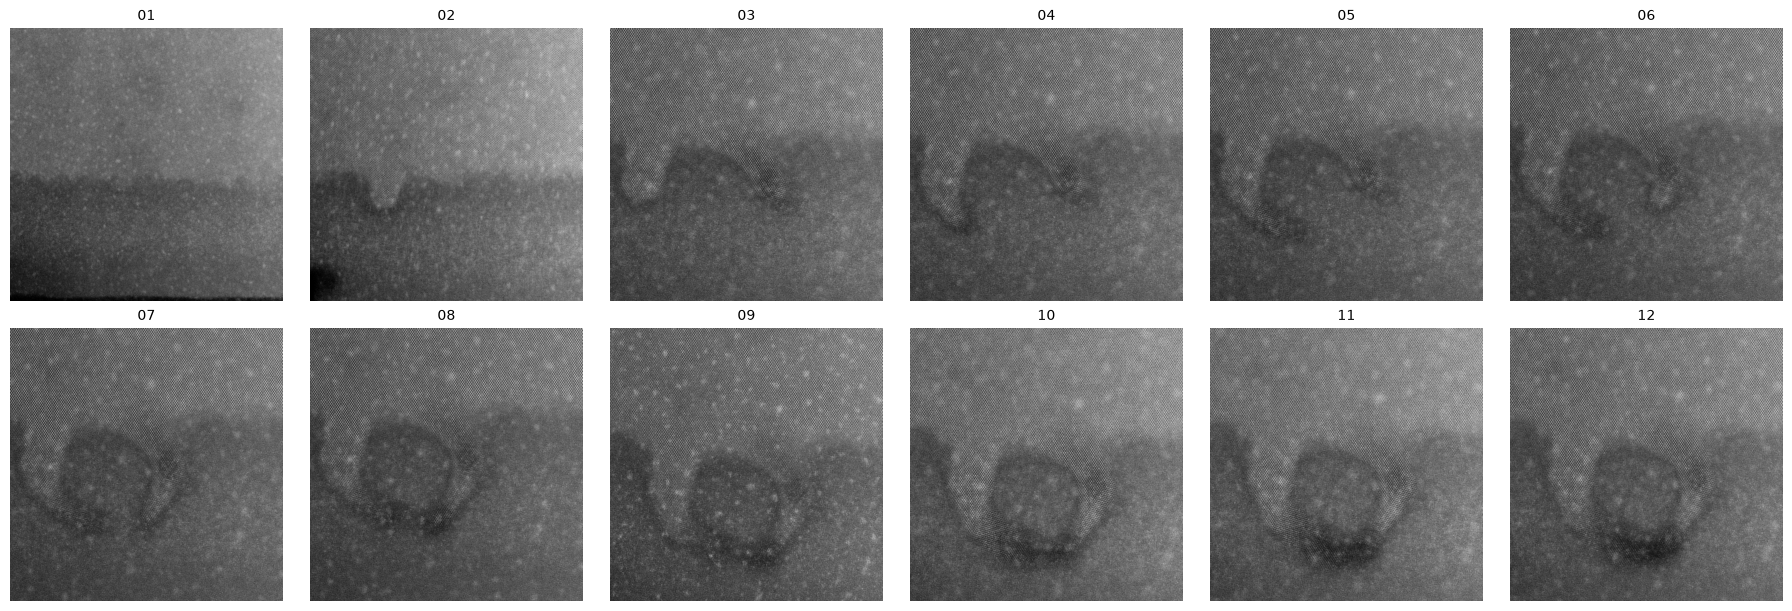

In [4]:
show_image_grid(
    sisb_images,
    titles=sisb_titles,
    rows=2,
)

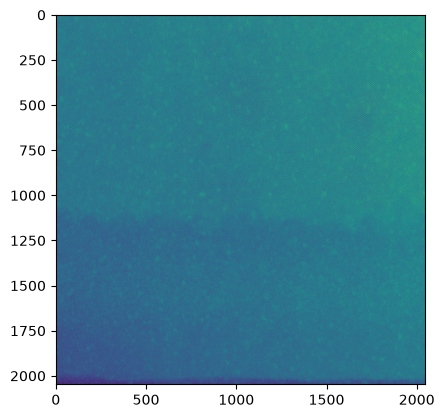

In [12]:
plt.imshow(sisb_images[0])

### Human ground truth

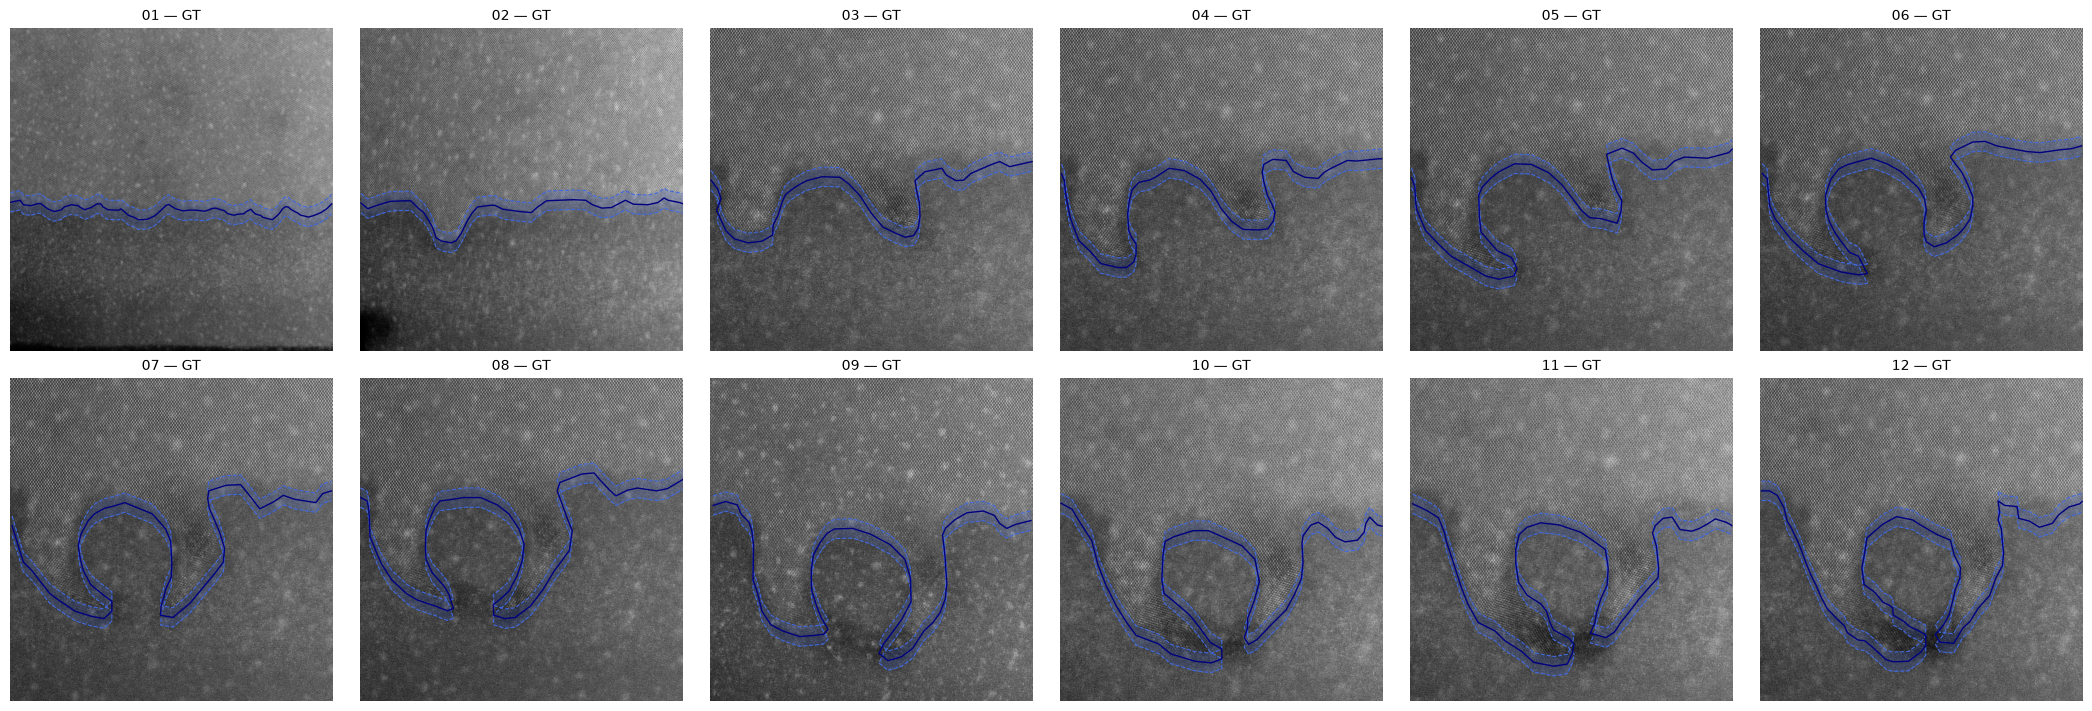

In [13]:
plot_ground_truth_grid(
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    rows=2,
)

## 3. Build your boundary detector

A simple texture-based baseline is provided.

You may completely replace the code between the two markers.  
Do **not** change the function name, input, or required output format.

In [19]:
def detect_boundary(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Estimate local texture using local variance
    sigma_texture = 7

    local_mean = ndimage.gaussian_filter(
        x,
        sigma=sigma_texture
    )

    local_mean_squared = ndimage.gaussian_filter(
        x**2,
        sigma=sigma_texture
    )

    local_variance = np.maximum(
        local_mean_squared - local_mean**2,
        0
    )

    # 3. Smooth the texture map
    texture = ndimage.gaussian_filter(
        local_variance,
        sigma=1
    )

    # 4. Separate the two texture regimes
    threshold = np.median(texture)
    phase_mask = texture > threshold

    # 5. Clean the phase segmentation
    phase_mask = ndimage.binary_opening(
        phase_mask,
        iterations=2
    )

    phase_mask = ndimage.binary_closing(
        phase_mask,
        iterations=1
    )

    # 6. Extract the interface
    dilated = ndimage.binary_dilation(
        phase_mask,
        iterations=1
    )

    eroded = ndimage.binary_erosion(
        phase_mask,
        iterations=1
    )

    boundary = dilated ^ eroded

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return boundary.astype(bool)

### Method 1

In [21]:
def estimate_lattice_period(x, crop=1024):
    """
    Find the typical distance (in pixels) between lattice fringes.

    Idea: a crystal lattice is periodic, so in the Fourier transform it shows up
    as a bright spot at a distance r from the center. The period is N / r.
    """

    # 1. Take a square from the middle of the image (fast, and enough to see the lattice)
    h, w = x.shape
    n = min(crop, h, w)
    y0 = (h - n) // 2
    x0 = (w - n) // 2
    c = x[y0:y0 + n, x0:x0 + n]

    # 2. Remove the mean and apply a window, so the edges of the crop do not create fake frequencies
    c = c - c.mean()
    window = np.hanning(n)[:, None] * np.hanning(n)[None, :]

    # 3. Fourier transform, move the zero frequency to the center, take the magnitude
    F = np.abs(np.fft.fftshift(np.fft.fft2(c * window)))

    # 4. Distance of every Fourier pixel from the center
    yy, xx = np.mgrid[:n, :n]
    r = np.hypot(yy - n // 2, xx - n // 2)

    # 5. Ignore very low frequencies (slow background changes, period > n/8 px)
    #    and very high frequencies (noise, period < 3 px)
    F[r < 8] = 0
    F[r > n / 3] = 0

    # 6. The brightest remaining spot is the lattice reflection
    r_peak = r[np.unravel_index(F.argmax(), F.shape)]

    # 7. Convert the distance in Fourier space to a period in real space
    period = n / r_peak

    return float(period)

In [22]:
for image, title in zip(sisb_images, sisb_titles):
    x = robust_normalize(image)
    print(title, f"period = {estimate_lattice_period(x):.1f} px")

01 period = 7.1 px
02 period = 10.1 px
03 period = 14.2 px
04 period = 14.2 px
05 period = 14.2 px
06 period = 14.2 px
07 period = 8.7 px
08 period = 8.7 px
09 period = 14.2 px
10 period = 14.4 px
11 period = 14.4 px
12 period = 14.4 px


In [23]:
def lattice_energy_map(x, period, smooth_periods=2.0):
    """
    Local strength of the lattice fringes, for every pixel.

    Idea: keep only the image frequencies near the lattice period (band-pass),
    square the result (power), and average it over a few periods.
    Crystal -> high values. Amorphous -> low values.
    """

    # 1. Band-pass filter = difference of two Gaussian blurs.
    #    The narrow blur keeps the lattice, the wide blur keeps only the background.
    #    Their difference keeps the lattice and removes the background.
    sigma_narrow = 0.25 * period
    sigma_wide = 0.60 * period

    band = (
        ndimage.gaussian_filter(x, sigma_narrow)
        - ndimage.gaussian_filter(x, sigma_wide)
    )

    # 2. Square it: fringes oscillate around zero, the square is always positive
    power = band ** 2

    # 3. Average the power over a few lattice periods.
    #    This turns the fast oscillation into a smooth "how strong is the lattice here" map.
    energy = ndimage.gaussian_filter(power, smooth_periods * period)

    return energy

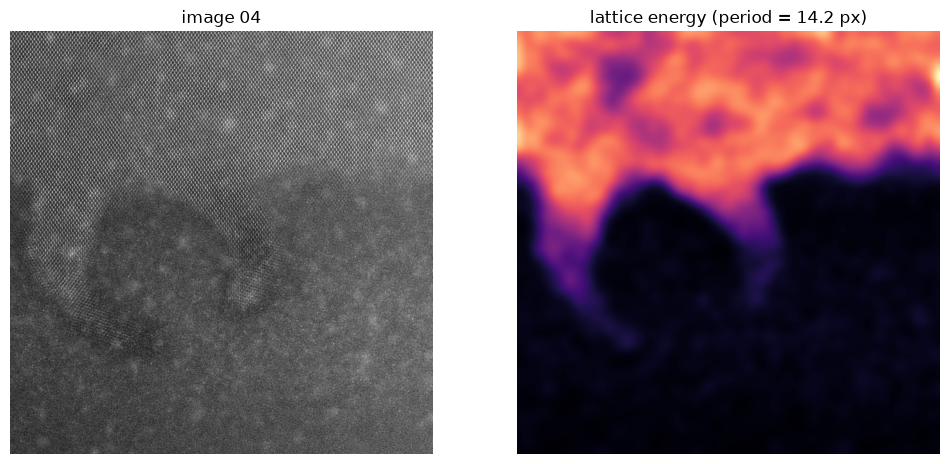

In [27]:
x = robust_normalize(sisb_images[5])
period = estimate_lattice_period(x)
energy = lattice_energy_map(x, period)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(x, cmap="gray")
ax[0].set_title("image 04")
ax[1].imshow(energy, cmap="magma")
ax[1].set_title(f"lattice energy (period = {period:.1f} px)")
for a in ax:
    a.axis("off")
plt.show()

In [28]:
def estimate_floor(energy, low_fraction=0.30):
    """
    Level and noise of the lattice energy in the amorphous region.

    Idea: the amorphous region has the lowest energy values in the image.
    We take the lowest 30% of all pixels and assume they are pure amorphous.
    A median and a MAD (median absolute deviation) are used because they
    are not disturbed by a few outliers.
    """

    # 1. Keep only the low-energy pixels (assumed amorphous)
    cutoff = np.percentile(energy, 100 * low_fraction)
    low_values = energy[energy <= cutoff]

    # 2. Typical amorphous level = median of those pixels
    floor = np.median(low_values)

    # 3. Noise of the amorphous level = MAD, scaled to be comparable to a standard deviation
    floor_noise = 1.4826 * np.median(np.abs(low_values - floor))

    # 4. Typical crystal level, for reference (90th percentile of the whole image)
    crystal = np.percentile(energy, 90)

    return float(floor), float(floor_noise), float(crystal)

In [26]:
for index in [0, 3, 9]:
    x = robust_normalize(sisb_images[index])
    period = estimate_lattice_period(x)
    energy = lattice_energy_map(x, period)
    floor, floor_noise, crystal = estimate_floor(energy)

    print(
        sisb_titles[index],
        f"floor = {floor:.2e}",
        f"noise = {floor_noise:.2e}",
        f"crystal = {crystal:.2e}",
        f"contrast = {(crystal - floor) / floor_noise:.0f} sigma",
    )

01 floor = 2.55e-04 noise = 4.04e-05 crystal = 1.80e-03 contrast = 38 sigma
04 floor = 1.70e-04 noise = 2.21e-05 crystal = 1.80e-03 contrast = 74 sigma
10 floor = 1.93e-04 noise = 2.69e-05 crystal = 1.19e-03 contrast = 37 sigma


In [29]:
def keep_large_regions(mask, min_area):
    """Keep only connected regions of the mask that have at least min_area pixels."""

    labels, n_regions = ndimage.label(mask)
    if n_regions == 0:
        return mask

    # Size of every region (index 0 is the background, ignore it)
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0

    # Labels of the regions that are large enough
    large = np.flatnonzero(sizes >= min_area)

    return np.isin(labels, large)


def coarse_crystal_mask(energy, floor, crystal, level=0.30, min_area_fraction=0.005):
    """
    First rough separation: True = crystal, False = amorphous.

    Idea: threshold the energy at 30% of the way from the amorphous floor to
    the crystal level. This is safe and gives a clean mask, but the edge is
    still some tens of pixels inside the crystal. Step 5 will fix that.
    """

    # 1. Threshold between floor and crystal
    threshold = floor + level * (crystal - floor)
    mask = energy > threshold

    # 2. Remove small crystal islands inside the amorphous region
    min_area = min_area_fraction * mask.size
    mask = keep_large_regions(mask, min_area)

    # 3. Remove small amorphous islands inside the crystal
    #    (invert, clean, invert back). Large amorphous pockets survive.
    mask = ~keep_large_regions(~mask, min_area)

    return mask

crystal regions: 1  amorphous regions: 1


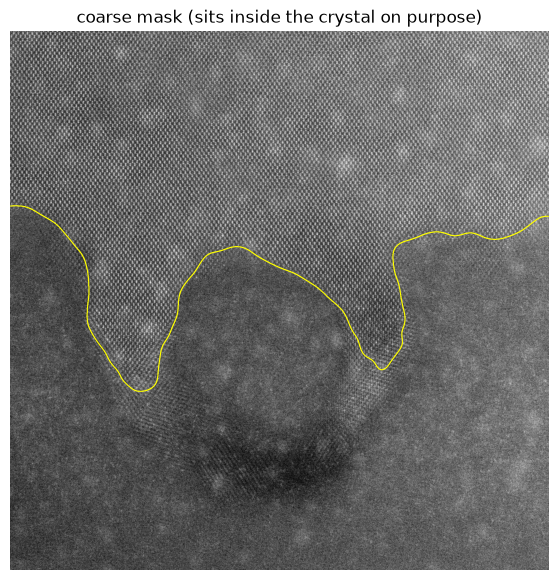

In [32]:
x = robust_normalize(sisb_images[-1])
period = estimate_lattice_period(x)
energy = lattice_energy_map(x, period)
floor, floor_noise, crystal = estimate_floor(energy)
mask = coarse_crystal_mask(energy, floor, crystal)

print("crystal regions:", ndimage.label(mask)[1], " amorphous regions:", ndimage.label(~mask)[1])

plt.figure(figsize=(7, 7))
plt.imshow(x, cmap="gray")
plt.contour(mask, colors="yellow", linewidths=0.8)
plt.axis("off")
plt.title("coarse mask (sits inside the crystal on purpose)")
plt.show()

In [33]:
def grow_to_floor(coarse_mask, energy, floor, floor_noise, k=3.0, min_area_fraction=0.005):
    """
    Extend the coarse crystal region outward to the point where the lattice
    energy falls back to the amorphous floor.

    Idea: every pixel with energy above (floor + k * noise) is "possibly crystal".
    We keep only the possibly-crystal pixels that touch the coarse crystal region.
    So the region grows along the ramp and stops where the ramp reaches the floor.
    """

    # 1. Pixels that are still clearly above the amorphous floor
    above_floor = energy > floor + k * floor_noise

    # 2. Split those pixels into connected pieces
    labels, n_pieces = ndimage.label(above_floor)

    # 3. Find which pieces touch the coarse crystal region
    touching = np.unique(labels[coarse_mask])
    touching = touching[touching > 0]        # label 0 is background

    # 4. The grown crystal = those pieces, plus the coarse region itself
    grown = np.isin(labels, touching) | coarse_mask

    # 5. Remove small amorphous holes that appear inside the grown region
    min_area = min_area_fraction * grown.size
    grown = ~keep_large_regions(~grown, min_area)

    return grown

In [76]:
def remove_thin_parts(grown_mask, coarse_mask, radius):
    """
    Remove crystal parts thinner than 2 * radius (noise leaks look like thin tendrils).

    Idea: shrink the region by `radius`, then grow it back by `radius` (an "opening").
    Anything thinner than 2 * radius vanishes and does not come back.
    Done with distance transforms, which is fast for large radii.
    """

    # 1. Shrink: keep only pixels deeper than `radius` inside the region
    eroded = ndimage.distance_transform_edt(grown_mask) > radius

    # 2. Grow back by the same distance
    opened = ndimage.distance_transform_edt(~eroded) <= radius

    # 3. The opening can cut a leak off and leave it as a separate island:
    #    keep only the pieces that still touch the coarse crystal region
    labels, _ = ndimage.label(opened)
    touching = np.unique(labels[coarse_mask])
    touching = touching[touching > 0]

    return np.isin(labels, touching)

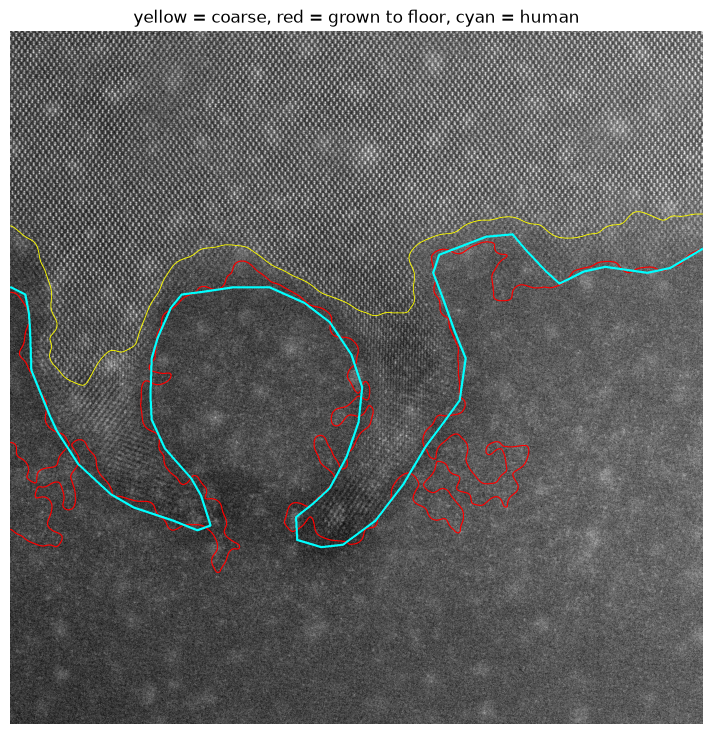

In [75]:
from utils import load_ground_truth

index = 7
x = robust_normalize(sisb_images[index])
period = estimate_lattice_period(x)
energy = lattice_energy_map(x, period)
floor, floor_noise, crystal = estimate_floor(energy)
coarse = coarse_crystal_mask(energy, floor, crystal)
grown = grow_to_floor(coarse, energy, floor, floor_noise)

gt = load_ground_truth(sisb_files[index], GT_DIR)

plt.figure(figsize=(9, 9))
plt.imshow(x, cmap="gray")
plt.contour(coarse, colors="yellow", linewidths=0.6)   # step 4
plt.contour(grown, colors="red", linewidths=0.8)       # step 5
plt.contour(gt, colors="cyan", linewidths=0.8)         # human
plt.axis("off")
plt.title("yellow = coarse, red = grown to floor, cyan = human")
plt.show()

In [78]:
def detect_boundary_new(image):
    """
    Crystalline–amorphous boundary detector.
    Input:  2D image (any brightness / contrast).
    Output: 2D boolean array, same shape, True on the boundary line.
    """

    # 1. Normalize intensities to 0..1 (same helper the baseline uses)
    x = robust_normalize(image)

    # 2. Measure the lattice period from the FFT, so all later scales adapt to magnification
    period = estimate_lattice_period(x)

    # 3. Lattice energy map: high in the crystal, low in the amorphous region
    energy = lattice_energy_map(x, period)

    # 4. Level and noise of the amorphous floor, measured from this image
    floor, floor_noise, crystal = estimate_floor(energy)

    # 5. Coarse crystal region (clean, single region, but edge sits inside the crystal)
    coarse = coarse_crystal_mask(energy, floor, crystal)

    # 6. Grow the region outward until the energy reaches the floor
    grown = grow_to_floor(coarse, energy, floor, floor_noise)

    # 6. Grow the region outward until the energy reaches the floor
    grown = grow_to_floor(coarse, energy, floor, floor_noise)

    # 6b. Remove leaks: crystal cannot be thinner than ~3 lattice periods
    grown = remove_thin_parts(grown, coarse, radius=1.5 * period)

    # 7. Smooth the edge of the mask at the scale of a few lattice periods.
    #    Blurring a 0/1 mask and cutting at 0.5 removes pixel-level raggedness
    #    without moving a straight edge.
    smooth = ndimage.gaussian_filter(grown.astype(float), 3 * period) > 0.5

    # # 8. Apply the "one boundary" assumption once more after smoothing
    min_area = 0.01 * smooth.size
    smooth = keep_large_regions(smooth, min_area)        # no small crystal islands
    smooth = ~keep_large_regions(~smooth, min_area)      # no small amorphous islands

    # 9. Turn the region into a one-pixel-wide line: (dilated) XOR (eroded)
    boundary = ndimage.binary_dilation(grown) ^ ndimage.binary_erosion(grown)

    # 10. Never mark the image border as a boundary
    boundary[0, :] = False
    boundary[-1, :] = False
    boundary[:, 0] = False
    boundary[:, -1] = False

    return boundary.astype(bool)

In [79]:
from utils import load_ground_truth

def plot_all_predictions(detector, images, files, titles, gt_dir, rows=2):
    """
    Show every image with the human boundary (cyan) and the prediction (red).
    """

    n = len(images)
    cols = int(np.ceil(n / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, image, file, title in zip(axes, images, files, titles):

        # 1. Human boundary and our prediction
        gt = load_ground_truth(file, gt_dir)
        pred = detector(image)

        # 2. Make the thin lines visible at this small scale
        gt_thick = ndimage.binary_dilation(gt, iterations=3)
        pred_thick = ndimage.binary_dilation(pred, iterations=3)

        # 3. Draw image, then both lines
        ax.imshow(robust_normalize(image), cmap="gray")
        ax.contour(gt_thick, levels=[0.5], colors="cyan", linewidths=0.8)
        ax.contour(pred_thick, levels=[0.5], colors="red", linewidths=0.8)
        ax.set_title(title)
        ax.axis("off")

    # Hide unused panels
    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

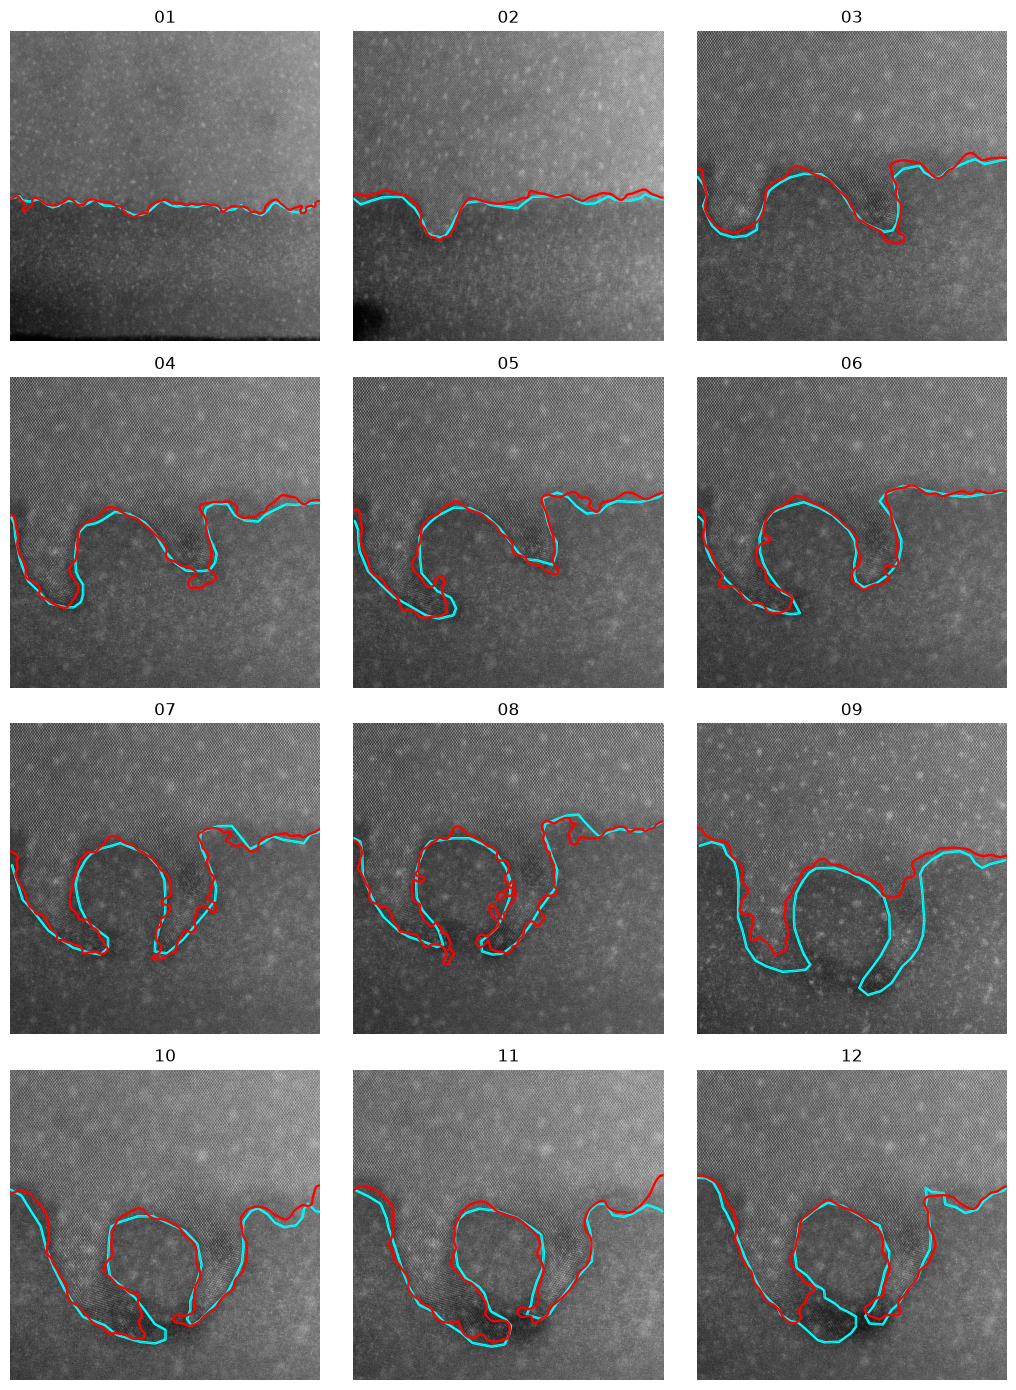

In [80]:
plot_all_predictions(detect_boundary_new, sisb_images, sisb_files, sisb_titles, GT_DIR, rows=4)

## 4. Test one image visually

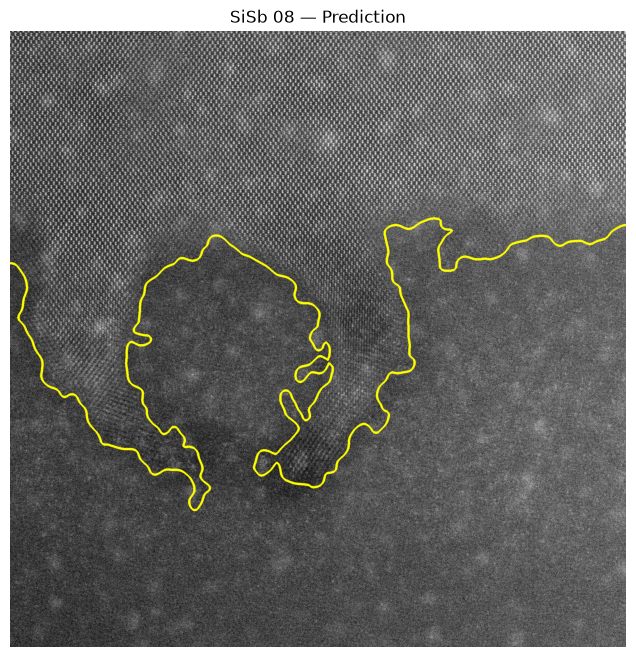

In [81]:
example_index = 7

image = sisb_images[example_index]
boundary = detect_boundary_new(image)

plot_boundary_result(
    image,
    boundary,
    title=f"SiSb {sisb_titles[example_index]} — Prediction",
)

## 5. Challenge 1 evaluation

We evaluate only three things:

### 1. Accuracy against human ground truth
Predictions are compared with the hand-drawn boundary using a spatial tolerance. Exact single-pixel agreement is not required.

Primary metric: **F1 @ 5 px tolerance**

### 2. Robustness
The same detector is tested after controlled perturbations:
- Gaussian noise
- Gaussian blur
- brightness change
- contrast change
- inclined intensity background

Every perturbed prediction is compared with the **same human ground truth**.

### 3. Speed
Only `detect_boundary(image)` is timed. File loading, plotting, and scoring are excluded.

### Test 1 — Accuracy against ground truth

In [82]:
accuracy_results = evaluate_against_ground_truth(
    detect_boundary_new,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=50,
)

accuracy_results

,image,precision,recall,f1,mean_pred_to_gt_distance,mean_gt_to_pred_distance,mean_symmetric_boundary_error
0,01,0.979649,1.000000,0.989720,10.522871,8.496800,9.509835
1,02,0.995472,0.977527,0.986418,20.203546,20.725888,20.464717
2,03,0.874375,0.975216,0.922046,21.549319,15.952593,18.750956
3,04,0.900531,0.974019,0.935834,22.727008,17.231311,19.979160
4,05,0.865519,0.939143,0.900829,23.522028,19.477522,21.499775
5,06,0.975743,0.981893,0.978808,15.361100,14.475625,14.918363
6,07,0.923607,0.981081,0.951477,21.237064,17.515587,19.376326
7,08,0.854251,0.963658,0.905662,25.912155,14.406530,20.159342
8,09,0.606967,0.416598,0.494079,48.160541,152.674973,100.417757
9,10,0.878016,0.867234,0.872592,23.389092,24.450027,23.919560


In [83]:
summarize_accuracy(
    accuracy_results
)

mean_precision             0.892685
mean_recall                0.905534
mean_f1                    0.896508
mean_boundary_error_px    26.369775
Name: Clean boundary accuracy, dtype: float64

### Test 2 — Robustness

In [84]:
robustness_results = evaluate_robustness(
    detect_boundary_new,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=5,
    max_images=4,
)

robustness_summary = summarize_robustness(
    robustness_results
)

robustness_summary

,condition,mean_f1,std_f1,mean_precision,mean_recall,mean_boundary_error_px,f1_drop_from_clean
0,Clean,0.262920,0.071468,0.260590,0.268454,18.936690,0.000000
1,Gaussian noise 5%,0.246953,0.074347,0.243646,0.254792,21.241103,0.015967
2,Gaussian blur sigma=1,0.187693,0.040504,0.189186,0.189578,23.923510,0.075227
3,Brightness +10%,0.262920,0.071468,0.260590,0.268454,18.936690,0.000000
4,Contrast -20%,0.262920,0.071468,0.260590,0.268454,18.936690,0.000000
5,Intensity gradient 20%,0.266832,0.079888,0.259515,0.275929,16.599010,-0.003912


Interpretation:

- `mean_f1`: accuracy under that condition
- `mean_boundary_error_px`: average symmetric distance to the human boundary
- `f1_drop_from_clean`: performance lost relative to the clean images

**Smaller F1 drop is better.**

### Test 3 — Speed

In [85]:
speed_results = evaluate_speed(
    detect_boundary_new,
    sisb_images,
    repeats=5,
)

summarize_speed(
    speed_results
)

mean_seconds_per_image      2.703115
median_seconds_per_image    2.787732
slowest_seconds             3.826078
images_per_second           0.369944
Name: Speed, dtype: float64

# Challenge 2 — Atom Finding in YBCO

## Goal

Write:

```python
positions = find_atoms(image)
```

The function must return a NumPy array of shape `(N, 2)`.

Each row is:

```text
[y, x]
```

in pixel coordinates.

## 6. Load YBCO

In [ ]:
ybco_files = list_emd_files(YBCO_DIR)

ybco_images = [
    load_haadf(file)
    for file in ybco_files
]

ybco_titles = [
    file.stem
    for file in ybco_files
]

print(f"Found {len(ybco_images)} YBCO images")

if ybco_images:
    show_image_grid(
        ybco_images,
        titles=[
            str(i + 1)
            for i in range(len(ybco_images))
        ],
        rows=1 if len(ybco_images) > 1 else 1,
    )

## 7. Build your atom finder

A simple local-maximum baseline is provided.

You may completely replace the code between the two markers.

In [ ]:
def find_atoms(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Smooth
    smooth = ndimage.gaussian_filter(
        x,
        sigma=1.0
    )

    # 3. Find local maxima
    neighborhood = 5

    local_max = (
        smooth
        == ndimage.maximum_filter(
            smooth,
            size=neighborhood,
            mode="reflect",
        )
    )

    # 4. Keep only bright maxima
    intensity_threshold = np.percentile(
        smooth,
        97.0,
    )

    peaks = (
        local_max
        & (smooth >= intensity_threshold)
    )

    # 5. Convert peaks to [y, x]
    positions = np.argwhere(peaks)

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return np.asarray(
        positions
    ).reshape(-1, 2).astype(float)

## 8. Test one YBCO image visually

In [ ]:
if ybco_images:

    atom_example_index = 0

    atom_positions = find_atoms(
        ybco_images[atom_example_index]
    )

    validate_atom_output(
        ybco_images[atom_example_index],
        atom_positions,
    )

    plot_atom_result(
        ybco_images[atom_example_index],
        atom_positions,
        title="YBCO atom finding",
    )

## 9. Challenge 2 engineering tests

Until atom ground truth is added, these measure **consistency and robustness**, not true atom-detection accuracy.

In [ ]:
if ybco_images:
    atom_noise_results = atom_noise_robustness(
        find_atoms,
        ybco_images,
        noise_levels=(0.01, 0.03, 0.05, 0.10),
        tolerance=2.0,
    )

atom_noise_results

In [ ]:
if ybco_images:
    atom_photometric_results = atom_photometric_robustness(
        find_atoms,
        ybco_images,
        tolerance=2.0,
    )

atom_photometric_results

In [ ]:
if ybco_images:

    atom_speed_results = evaluate_speed(
        find_atoms,
        ybco_images,
        repeats=5,
    )

summarize_speed(
        atom_speed_results
    )

# 10. Reflection

At the end of the session, be ready to explain:

1. What approach did you use?
2. Which parameters matter most?
3. Where does it fail?
4. What would you improve next?
5. If AI helped write code, what did it generate?
6. What did you personally change?

> A good scientific algorithm is not just one that gives a nice picture.  
> You should be able to explain **how accurate, robust, and fast it is**.